# Model Training

## Imports of all the required libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import os
import sys
import matplotlib.pyplot as plt

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))

In [3]:
from models.baseline_model import BaselineModel
from models.improved_model import Improved_Model
from models.pretrained_model import get_resnet_model

## Parameter definitionm

In [4]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Data Transformation and Augmentation

In [5]:
# Simple Transformation for Baseline Model
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # --- Attempt 1
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # --- Attempt 2: Prefered Normalization
])

# Data Augmentation for Further Models (Improved and Pre-trained)
# - Random Horizontal Flip
# - Random Vertical Flip
# - Random Rotation
augmented_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Data Loading Pipeline

In [6]:
# Initialize standard and augmented DataLoaders for model training, validation, and testing
simple_train_set = datasets.ImageFolder(root='../../data/processed_data/train', transform=simple_transform)
simple_val_set = datasets.ImageFolder(root='../../data/processed_data/val', transform=simple_transform)
augmented_train_set = datasets.ImageFolder(root='../../data/processed_data/train', transform=augmented_transform)
augmented_val_set = datasets.ImageFolder(root='../../data/processed_data/val', transform=augmented_transform)

test_set = datasets.ImageFolder(root='../../data/processed_data/test')

simple_train_loader = DataLoader(simple_train_set, batch_size=BATCH_SIZE, shuffle=True)
simple_val_loader = DataLoader(simple_val_set, batch_size=BATCH_SIZE, shuffle=False)

augmented_train_loader = DataLoader(augmented_train_set, batch_size=BATCH_SIZE, shuffle=True)
augmented_val_loader = DataLoader(augmented_val_set, batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

## Model Training Loop

In [7]:
# Define Traning Logic
def train_model(model, model_name, train_loader, val_loader, epochs, lr, isScheduler=False):
    model = model.to(DEVICE) # Move model to GPU or CPU 
    criterion = nn.CrossEntropyLoss() # Define a Loss Function
    # Define a optimizer
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr) # --- Attempt 1: Prefered Optimizer 
    # optimizer = optim.RMSprop(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, alpha=0.99) # --- Attempt 2
    
    scheduler = None
    if (isScheduler):
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    
    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        
        train_bar = tqdm(train_loader, desc=f"{model_name} - Epoch {epoch+1}/{epochs}")
        
        for images, labels in train_bar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            # Backpropagation
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(train_loader)
        
        # --- VALIDATION ---
        model.eval()
        correct, total = 0, 0

        val_bar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Val", unit="batch", leave=False)
        
        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total

        if scheduler is not None:
            scheduler.step(val_acc)
        
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Result: Loss {avg_loss:.4f} | Val Acc {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model, f"{model_name}.pt")
            print(f"Saved Best {model_name} with {val_acc:.2f}% accuracy")
            
    return history

In [8]:
def plot_learning_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Training Loss')
    plt.title(f'{model_name}: Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    # Plot 2: Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], 'b-o', label='Val Accuracy')
    plt.title(f'{model_name}: Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Training Baseline Model

In [9]:
model1 = BaselineModel()
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.001) #--- Attempt 1
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.01) #--- Attempt 2
history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.0001) #--- Attempt 3: Prefered Parameter
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 25, lr = 0.00005) #---  Attempt 4

model1_baseline - Epoch 1/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.68it/s, loss=0.782]
                                                                                                                                                                                                                              

Result: Loss 1.3879 | Val Acc 68.27%
Saved Best model1_baseline with 68.27% accuracy


model1_baseline - Epoch 2/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.05it/s, loss=0.803]
                                                                                                                                                                                                                              

Result: Loss 0.8271 | Val Acc 73.68%
Saved Best model1_baseline with 73.68% accuracy


model1_baseline - Epoch 3/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.08it/s, loss=0.993]
                                                                                                                                                                                                                              

...

Result: Loss 0.1649 | Val Acc 92.62%
Saved Best model1_baseline with 92.62% accuracy


model1_baseline - Epoch 14/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.15it/s, loss=0.0174]
                                                                                                                                                                                                                              

Result: Loss 0.1554 | Val Acc 93.51%
Saved Best model1_baseline with 93.51% accuracy


model1_baseline - Epoch 15/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:37<00:00,  7.97it/s, loss=0.0568]
                                                                                                                                                                                                                              

Result: Loss 0.1373 | Val Acc 93.80%
Saved Best model1_baseline with 93.80% accuracy


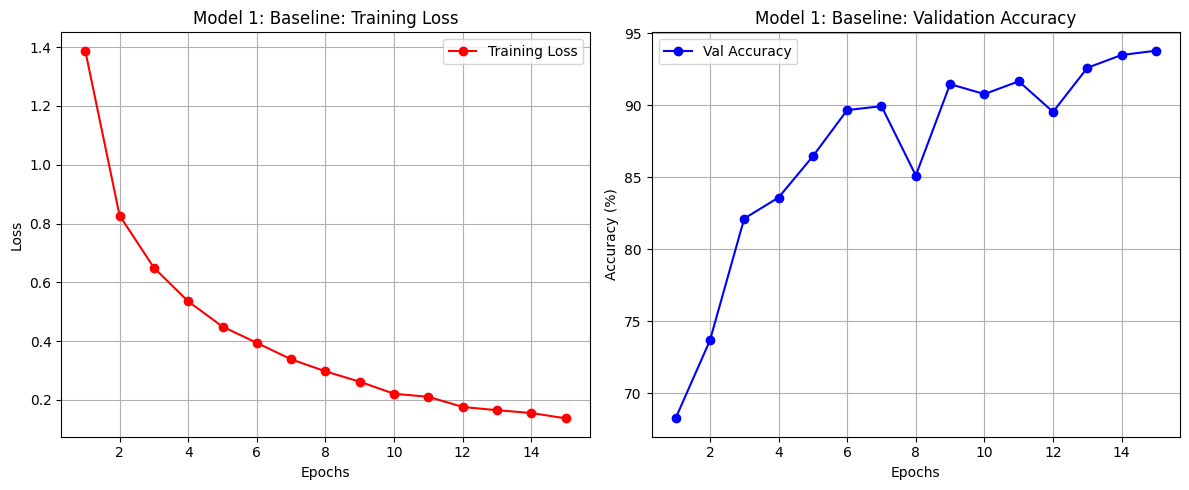

In [10]:
plot_learning_curves(history1, "Model 1: Baseline")

### Training Improved Model

In [15]:
model2 = Improved_Model()
history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 25, lr = 0.0001, isScheduler=True) # --- Attempt 1: Prefered Parameter
# history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 25, lr = 0.01, isScheduler=True) # --- Attempt 2
# history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.001, isScheduler=True) # --- Attempt 3
# history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 25, lr = 0.00005, isScheduler=True) # --- Attempt 4

model2_improved - Epoch 1/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:34<00:00,  8.56it/s, loss=0.612]
                                                                                                                                                                                                                              

Result: Loss 0.9854 | Val Acc 73.83%
Saved Best model2_improved with 73.83% accuracy


model2_improved - Epoch 2/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.68it/s, loss=0.764]
                                                                                                                                                                                                                              

Result: Loss 0.6808 | Val Acc 82.22%
Saved Best model2_improved with 82.22% accuracy


model2_improved - Epoch 3/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:34<00:00,  8.59it/s, loss=0.467]
                                                                                                                                                                                                                              

...

Result: Loss 0.1266 | Val Acc 95.11%


model2_improved - Epoch 24/25: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.08it/s, loss=0.0373]
                                                                                                                                                                                                                              

Result: Loss 0.1323 | Val Acc 95.33%


model2_improved - Epoch 25/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.01it/s, loss=0.334]
                                                                                                                                                                                                                              

Result: Loss 0.1162 | Val Acc 95.70%
Saved Best model2_improved with 95.70% accuracy


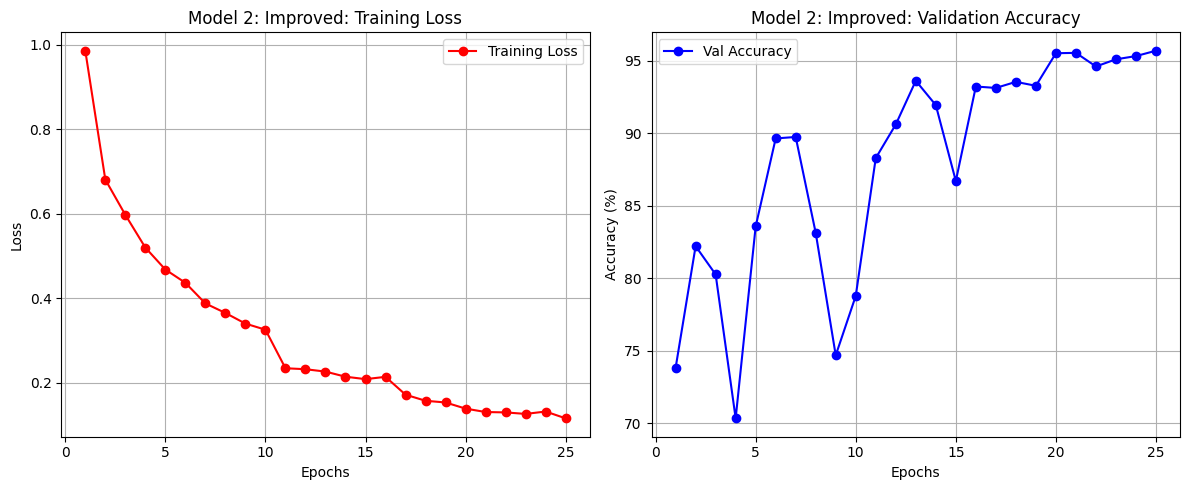

In [16]:
plot_learning_curves(history2, "Model 2: Improved")

### Training Pre-Trained Model

In [13]:
model3 = get_resnet_model()
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.0001, isScheduler=True) # --- Attempt 1
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.01, isScheduler=True) # --- Attempt 2
history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.001, isScheduler=True) # --- Attempt 3: Prefered Parameter
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.00005, isScheduler=True) # --- Attempt 4

model3_pretrained - Epoch 1/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.77it/s, loss=0.263]
                                                                                                                                                                                                                              

Result: Loss 0.2674 | Val Acc 95.95%
Saved Best model3_pretrained with 95.95% accuracy


model3_pretrained - Epoch 2/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.72it/s, loss=0.15]
                                                                                                                                                                                                                              

Result: Loss 0.1180 | Val Acc 97.21%
Saved Best model3_pretrained with 97.21% accuracy


model3_pretrained - Epoch 3/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:01<00:00,  4.80it/s, loss=0.515]
                                                                                                                                                                                                                              

...

Result: Loss 0.0253 | Val Acc 98.57%
Saved Best model3_pretrained with 98.57% accuracy


model3_pretrained - Epoch 14/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.77it/s, loss=0.00794]
                                                                                                                                                                                                                              

Result: Loss 0.0214 | Val Acc 98.59%
Saved Best model3_pretrained with 98.59% accuracy


model3_pretrained - Epoch 15/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:01<00:00,  4.83it/s, loss=0.0205]
                                                                                                                                                                                                                              

Result: Loss 0.0193 | Val Acc 98.44%


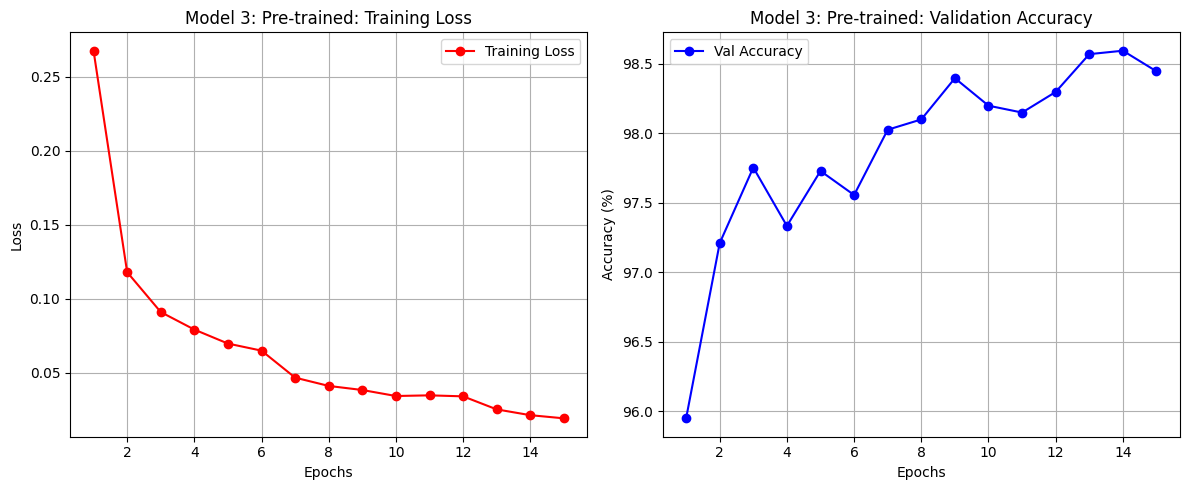

In [14]:
plot_learning_curves(history3, "Model 3: Pre-trained")